In [1]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [3]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:15<00:00, 10.7MB/s] 


In [4]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [5]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [6]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


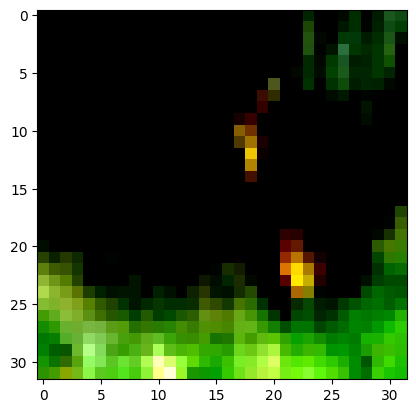

In [ ]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [8]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [9]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

Чуть дописала

In [14]:
config = {
    'num_epochs': 10,
    'lr': 1e-3,
    'batch_size': 128,
    'test_size': 0.2,
    'model_name': 'basiccnn', 
    'weight_decay': 1e-4,
    'num_workers': 2,
}

In [15]:

class Trainer:
    def __init__(self, config, transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        if self.config['model_name'].lower() == 'basiccnn':
            self.model = BasicCNN().to(self.device)
        elif self.config['model_name'].lower() == 'resnet18':
            self.model = ResNet18(num_classes=10).to(self.device)
        else:
            raise ValueError(f"Unknown model_name: {self.config['model_name']}")

        self.optimizer = Adam(
            self.model.parameters(),
            lr=self.config['lr'],
            weight_decay=self.config.get('weight_decay', 0.0),
        )
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
        }

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(
            list(range(len(train_dataset_full))),
            test_size=self.config['test_size'],
            random_state=42,
            shuffle=True
        )
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(
            dataset=train_dataset,
            batch_size=self.config['batch_size'],
            shuffle=True,
            num_workers=self.config.get('num_workers', 0),
            pin_memory=torch.cuda.is_available(),
        )
        self.val_loader = DataLoader(
            dataset=val_dataset,
            batch_size=self.config['batch_size'],
            shuffle=False,
            num_workers=self.config.get('num_workers', 0),
            pin_memory=torch.cuda.is_available(),
        )
        self.test_loader = DataLoader(
            dataset=test_dataset,
            batch_size=self.config['batch_size'],
            shuffle=False,
            num_workers=self.config.get('num_workers', 0),
            pin_memory=torch.cuda.is_available(),
        )

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            print(
                f"Epoch {epoch + 1}/{self.config['num_epochs']} | "
                f"train_loss={train_loss:.4f} | train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f} | val_acc={val_acc:.2f}%"
            )

        test_loss, test_acc = self.test_step()
        print(f"Test loss: {test_loss:.4f}, test acc: {test_acc:.2f}%")

        return self.history, {'test_loss': test_loss, 'test_acc': test_acc}

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        with torch.no_grad():
            for images, labels in tqdm(self.val_loader):
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        with torch.no_grad():
            for images, labels in tqdm(self.test_loader):
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc


In [16]:
trainer = Trainer(config, transform=transform)

In [17]:
history_basic, basic_metrics = trainer.run()

100%|██████████| 79/79 [00:15<00:00,  5.18it/s]


Epoch 1/10 | train_loss=1.5900 | train_acc=42.13% | val_loss=1.3410 | val_acc=50.93%


100%|██████████| 79/79 [00:15<00:00,  4.97it/s]


Epoch 2/10 | train_loss=1.2391 | train_acc=55.76% | val_loss=1.1849 | val_acc=58.09%


100%|██████████| 79/79 [00:14<00:00,  5.33it/s]


...

Epoch 9/10 | train_loss=0.7103 | train_acc=75.23% | val_loss=0.8489 | val_acc=70.81%


100%|██████████| 79/79 [02:05<00:00,  1.59s/it]


Epoch 10/10 | train_loss=0.6979 | train_acc=75.80% | val_loss=0.8468 | val_acc=70.76%


100%|██████████| 79/79 [00:17<00:00,  4.64it/s]

Test loss: 0.8648, test acc: 70.58%


# ResNet-18

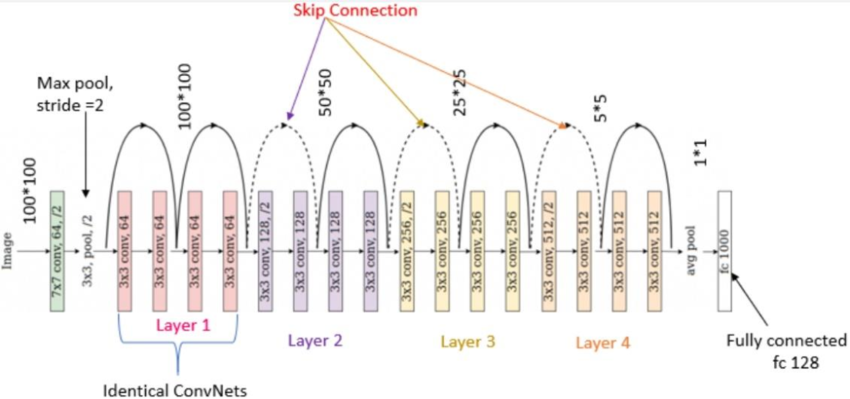

In [19]:

class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = out + identity
        out = self.relu(out)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64, blocks=2, stride=1)
        self.layer2 = self.make_layer(128, blocks=2, stride=2)
        self.layer3 = self.make_layer(256, blocks=2, stride=2)
        self.layer4 = self.make_layer(512, blocks=2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = [ResNetBlock(self.in_channels, out_channels, stride=stride, downsample=downsample)]
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResNetBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

## Сравнение BasicCNN и ResNet18 на 10 эпохах

In [21]:
config_basic = {
    **config,
    'model_name': 'basiccnn',
    'num_epochs': 10,
}

config_resnet = {
    **config,
    'model_name': 'resnet18',
    'num_epochs': 10,
}

trainer_basic = Trainer(config_basic, transform=transform)
history_basic, basic_metrics = trainer_basic.run()

trainer_resnet = Trainer(config_resnet, transform=transform)
history_resnet, resnet_metrics = trainer_resnet.run()

print('BasicCNN test metrics:', basic_metrics)
print('ResNet18 test metrics:', resnet_metrics)


100%|██████████| 79/79 [00:14<00:00,  5.29it/s]


Epoch 1/10 | train_loss=1.5736 | train_acc=42.52% | val_loss=1.3407 | val_acc=51.86%


100%|██████████| 79/79 [00:15<00:00,  5.14it/s]


Epoch 2/10 | train_loss=1.2223 | train_acc=56.23% | val_loss=1.1227 | val_acc=60.35%


100%|██████████| 79/79 [00:15<00:00,  5.07it/s]


...

Epoch 9/10 | train_loss=0.1388 | train_acc=95.55% | val_loss=0.8479 | val_acc=77.51%


100%|██████████| 79/79 [00:36<00:00,  2.17it/s]


Epoch 10/10 | train_loss=0.0926 | train_acc=97.13% | val_loss=0.9490 | val_acc=77.33%


100%|██████████| 79/79 [00:34<00:00,  2.26it/s]

Test loss: 1.0117, test acc: 76.14%
BasicCNN test metrics: {'test_loss': 0.8302888938143284, 'test_acc': 71.28}
ResNet18 test metrics: {'test_loss': 1.0116705045669894, 'test_acc': 76.14}


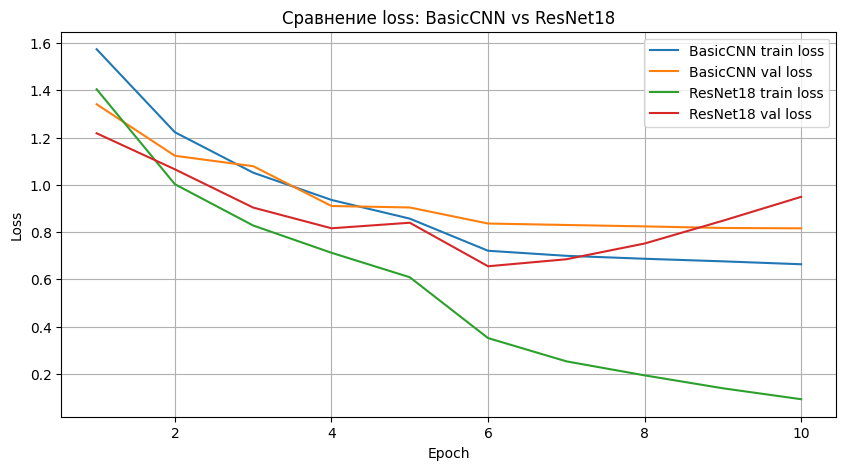

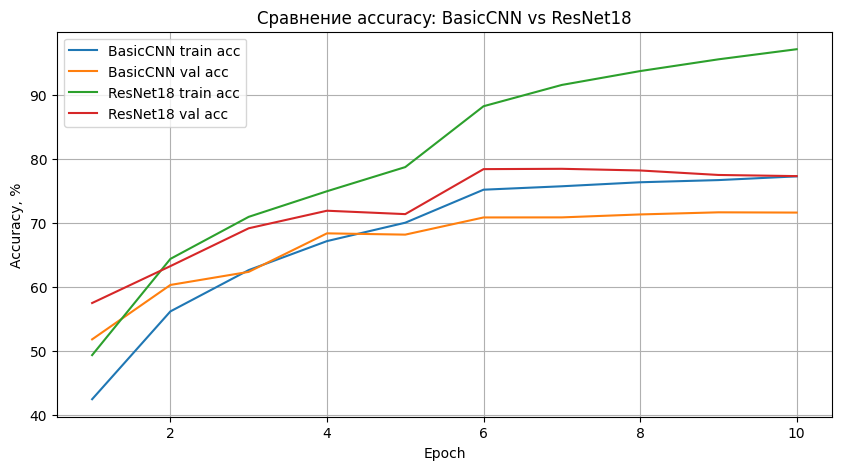

In [22]:
def plot_histories(history_a, history_b, label_a='BasicCNN', label_b='ResNet18'):
    epochs_a = range(1, len(history_a['train_loss']) + 1)
    epochs_b = range(1, len(history_b['train_loss']) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_a, history_a['train_loss'], label=f'{label_a} train loss')
    plt.plot(epochs_a, history_a['val_loss'], label=f'{label_a} val loss')
    plt.plot(epochs_b, history_b['train_loss'], label=f'{label_b} train loss')
    plt.plot(epochs_b, history_b['val_loss'], label=f'{label_b} val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Сравнение loss: BasicCNN vs ResNet18')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_a, history_a['train_acc'], label=f'{label_a} train acc')
    plt.plot(epochs_a, history_a['val_acc'], label=f'{label_a} val acc')
    plt.plot(epochs_b, history_b['train_acc'], label=f'{label_b} train acc')
    plt.plot(epochs_b, history_b['val_acc'], label=f'{label_b} val acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy, %')
    plt.title('Сравнение accuracy: BasicCNN vs ResNet18')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_histories(history_basic, history_resnet)


## Вывод

ResNet18 достигает более высокой точности на тестовой выборке, ток она переобучилась, модель начинает запоминать обучающие данные и хуже обобщает новые
